# Sparse Autoencoder (SAE) Training

Trains a SAE on hidden state activations collected from BERT or GPT-2.

**Pipeline:**
1. Load `.npy` activations
2. Grid search (expansion factor × L1 penalty) on a 10% subset
3. Plot reconstruction loss vs L0 — pick the Pareto-optimal config
4. Train final SAE on full activations
5. Save model weights and diagnostics

In [ ]:
import os
import json
import time
import itertools
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.cm as cm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Configuration

Set `MODEL` to `'bert'` or `'gpt2'` to select which activations to train on.

In [ ]:
# ── Select model ─────────────────────────────────────────────────────────────
MODEL       = 'bert'    # 'bert' or 'gpt2'
N_SPEECHES  = 1000000     # must match the number used when collecting activations

# ── Paths ─────────────────────────────────────────────────────────────────────
ACTIVATIONS_DIR = '/content/drive/MyDrive/EMI_Project/activations'
OUTPUT_DIR      = f'/content/drive/MyDrive/EMI_Project/activations/sae/{MODEL}'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ACT_PATH  = os.path.join(ACTIVATIONS_DIR, f'{MODEL}_last_{N_SPEECHES}.npy')
META_PATH = os.path.join(ACTIVATIONS_DIR, f'{MODEL}_metadata_{N_SPEECHES}.json')

# ── Grid search hyperparameters ───────────────────────────────────────────────
EXPANSION_FACTORS = [4, 8]
# L1 values scaled for sum-over-features formulation (not mean)
L1_COEFFS         = [1e-4, 5e-4, 1e-3]

SWEEP_FRACTION = 0.10   # fraction of data used for grid search
SWEEP_STEPS    = 8_000  # optimiser steps per sweep run (~fast)

# ── Final training ────────────────────────────────────────────────────────────
FINAL_STEPS    = 100_000
BATCH_SIZE     = 4096
LEARNING_RATE  = 1e-4
SEED           = 42

print(f'Activation file : {ACT_PATH}')
print(f'Output dir      : {OUTPUT_DIR}')

Activation file : /content/drive/MyDrive/EMI_Project/activations/bert_last_1000000.npy
Output dir      : /content/drive/MyDrive/EMI_Project/activations/sae/bert


## Load Activations

In [ ]:
assert os.path.isfile(ACT_PATH),  f'Activations not found: {ACT_PATH}'
assert os.path.isfile(META_PATH), f'Metadata not found: {META_PATH}'

print('Loading activations...')
activations_np = np.load(ACT_PATH).astype(np.float32)
print(f'Shape  : {activations_np.shape}   dtype: {activations_np.dtype}')
print(f'Min    : {activations_np.min():.4f}   Max: {activations_np.max():.4f}')
print(f'Memory : {activations_np.nbytes / 1e9:.2f} GB')

act_scale = float(np.sqrt((activations_np ** 2).mean()))
activations_np /= act_scale
print(f'Activation RMS scale: {act_scale:.4f}  (activations now unit-RMS)')


D_IN = activations_np.shape[1]
N    = activations_np.shape[0]
print(f'\nd_in = {D_IN}   n_activations = {N:,}')

# Centre activations — SAE pre-encoder bias handles the mean
act_mean = activations_np.mean(axis=0, keepdims=True)
activations_np -= act_mean
print('Activations centred (mean subtracted).')

activations_tensor = torch.from_numpy(activations_np)

Loading activations...
Shape  : (1000000, 768)   dtype: float32
Min    : -6.2635   Max: 1.6229
Memory : 3.07 GB
Activation RMS scale: 0.2966  (activations now unit-RMS)

d_in = 768   n_activations = 1,000,000
Activations centred (mean subtracted).


## SAE Architecture

Standard Anthropic-style SAE:
- **Encoder:** `Linear(d_in → d_sae)` + ReLU  
- **Decoder:** `Linear(d_sae → d_in)` with **unit-norm columns** (enforced after every step)  
- **Loss:** MSE reconstruction + λ · L1 on feature activations

In [ ]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in: int, d_sae: int):
        super().__init__()
        self.d_in  = d_in
        self.d_sae = d_sae

        self.W_enc = nn.Linear(d_in, d_sae, bias=True)
        self.W_dec = nn.Linear(d_sae, d_in, bias=True)

        # Initialise decoder columns to unit norm
        nn.init.orthogonal_(self.W_dec.weight)
        self._normalise_decoder()

    @torch.no_grad()
    def _normalise_decoder(self):
        """Project decoder weight columns onto the unit sphere."""
        self.W_dec.weight.data = F.normalize(self.W_dec.weight.data, dim=1)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.W_enc(x))

    def decode(self, f: torch.Tensor) -> torch.Tensor:
        return self.W_dec(f)

    def forward(self, x: torch.Tensor):
        f     = self.encode(x)
        x_hat = self.decode(f)
        return f, x_hat

    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters())


def sae_loss(x, f, x_hat, l1_coeff):
    recon = F.mse_loss(x_hat, x)
    # Sum over features, mean over batch — keeps L1 scale independent of d_sae
    sparsity = f.abs().sum(dim=-1).mean()
    return recon + l1_coeff * sparsity, recon, sparsity


def l0_norm(f):
    """Average number of active features per input."""
    return (f > 0).float().sum(dim=1).mean().item()


print('SAE class defined.')

SAE class defined.


## Training Function

In [ ]:
def train_sae(
    data: torch.Tensor,
    d_sae: int,
    l1_coeff: float,
    n_steps: int,
    batch_size: int = BATCH_SIZE,
    lr: float = LEARNING_RATE,
    seed: int = SEED,
    log_every: int = 1000,
    desc: str = '',
):
    torch.manual_seed(seed)
    d_in = data.shape[1]

    model = SparseAutoencoder(d_in, d_sae).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    loader = DataLoader(
        TensorDataset(data),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
    )

    history = {'step': [], 'loss': [], 'recon': [], 'l1': [], 'l0': []}

    step = 0
    t0   = time.time()

    while step < n_steps:
        for (batch,) in loader:
            if step >= n_steps:
                break

            batch = batch.to(device)
            f, x_hat = model(batch)
            loss, recon, sparsity = sae_loss(batch, f, x_hat, l1_coeff)

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
            model._normalise_decoder()

            if step % log_every == 0:
                with torch.no_grad():
                    l0 = l0_norm(f)
                history['step'].append(step)
                history['loss'].append(loss.item())
                history['recon'].append(recon.item())
                history['l1'].append(sparsity.item())
                history['l0'].append(l0)
                if desc:
                    print(f'  [{desc}] step {step:>6d}/{n_steps}  '
                          f'recon={recon.item():.4f}  l0={l0:.1f}', end='\r')

            step += 1

    elapsed = time.time() - t0
    if desc:
        print(f'  [{desc}] done in {elapsed:.0f}s  '
              f'final recon={history["recon"][-1]:.4f}  '
              f'l0={history["l0"][-1]:.1f}     ')

    return model, history


print('train_sae() defined.')

train_sae() defined.


## Grid Search

Sweeps 6 configs (2 expansion factors × 3 L1 coefficients) on a **10% subset**.  
Each run takes ~1–3 minutes on an A100.

In [ ]:
torch.manual_seed(SEED)
n_subset  = int(N * SWEEP_FRACTION)
idx       = torch.randperm(N)[:n_subset]
subset    = activations_tensor[idx]

print(f'Grid search subset: {n_subset:,} activations  ({SWEEP_FRACTION*100:.0f}% of {N:,})')
print(f'Configs: {len(EXPANSION_FACTORS)} expansion factors × {len(L1_COEFFS)} L1 coeffs '
      f'= {len(EXPANSION_FACTORS)*len(L1_COEFFS)} runs')
print(f'Steps per run: {SWEEP_STEPS:,}\n')

sweep_results = []

for exp, l1 in itertools.product(EXPANSION_FACTORS, L1_COEFFS):
    d_sae = D_IN * exp
    label = f'exp={exp}x  l1={l1:.0e}'
    print(f'Running: {label}  (d_sae={d_sae})')

    model, history = train_sae(
        data      = subset,
        d_sae     = d_sae,
        l1_coeff  = l1,
        n_steps   = SWEEP_STEPS,
        desc      = label,
    )

    sweep_results.append({
        'expansion':    exp,
        'l1_coeff':     l1,
        'd_sae':        d_sae,
        'label':        label,
        'final_recon':  history['recon'][-1],
        'final_l0':     history['l0'][-1],
        'history':      history,
    })

print('\nGrid search complete.')

Grid search subset: 100,000 activations  (10% of 1,000,000)
Configs: 2 expansion factors × 3 L1 coeffs = 6 runs
Steps per run: 8,000

Running: exp=4x  l1=1e-04  (d_sae=3072)
  [exp=4x  l1=1e-04] done in 195s  final recon=0.0076  l0=736.4     
Running: exp=4x  l1=5e-04  (d_sae=3072)
  [exp=4x  l1=5e-04] done in 194s  final recon=0.0265  l0=193.4     
Running: exp=4x  l1=1e-03  (d_sae=3072)
  [exp=4x  l1=1e-03] done in 194s  final recon=0.0420  l0=103.2     
Running: exp=8x  l1=1e-04  (d_sae=6144)
  [exp=8x  l1=1e-04] done in 195s  final recon=0.0075  l0=734.7     
Running: exp=8x  l1=5e-04  (d_sae=6144)
  [exp=8x  l1=5e-04] done in 195s  final recon=0.0261  l0=190.2     
Running: exp=8x  l1=1e-03  (d_sae=6144)
  [exp=8x  l1=1e-03] done in 194s  final recon=0.0419  l0=102.1     

Grid search complete.


## Results — Reconstruction Loss vs L0

Each point is one config. **Lower and further left is better.**  
The Pareto frontier (highlighted) shows configs where you can't improve one metric without hurting the other — pick from there.

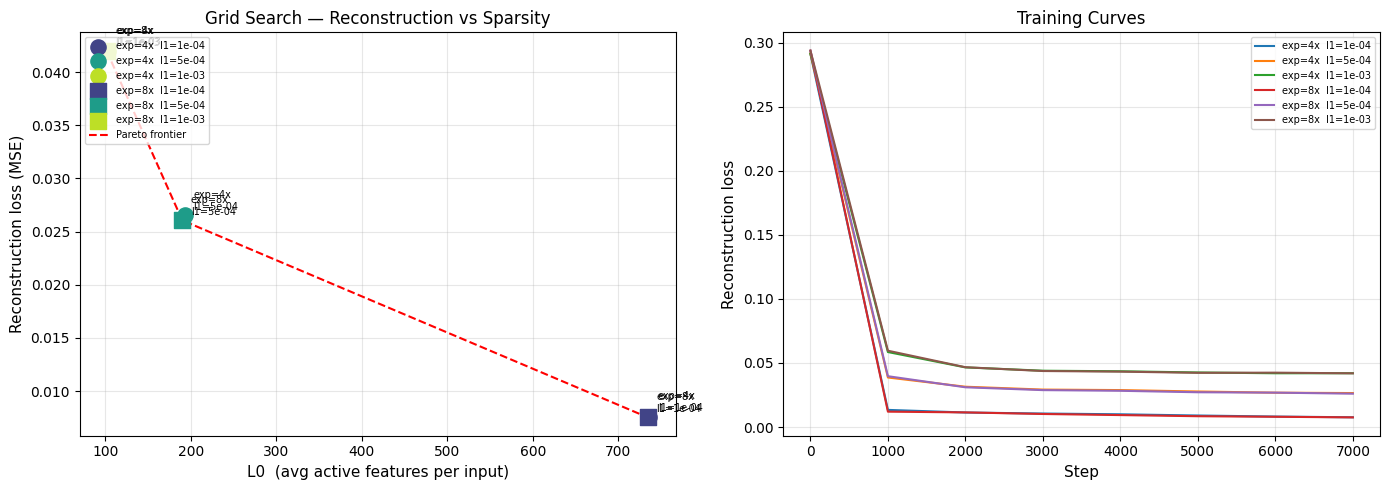

Saved: /content/drive/MyDrive/EMI_Project/activations/sae/bert/grid_search.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Pareto scatter ──────────────────────────────────────────────────────
ax = axes[0]
markers  = {4: 'o', 8: 's'}
colors   = cm.viridis(np.linspace(0.2, 0.9, len(L1_COEFFS)))
l1_color = {l1: colors[i] for i, l1 in enumerate(L1_COEFFS)}

for r in sweep_results:
    ax.scatter(
        r['final_l0'], r['final_recon'],
        marker=markers[r['expansion']],
        color=l1_color[r['l1_coeff']],
        s=120, zorder=3,
        label=r['label'],
    )
    ax.annotate(
        f"exp={r['expansion']}x\nl1={r['l1_coeff']:.0e}",
        (r['final_l0'], r['final_recon']),
        textcoords='offset points', xytext=(6, 4), fontsize=7,
    )

# Pareto frontier
sorted_r = sorted(sweep_results, key=lambda x: x['final_l0'])
pareto, best_recon = [], float('inf')
for r in sorted_r:
    if r['final_recon'] < best_recon:
        pareto.append(r)
        best_recon = r['final_recon']
if len(pareto) > 1:
    px = [r['final_l0']   for r in pareto]
    py = [r['final_recon'] for r in pareto]
    ax.plot(px, py, 'r--', lw=1.5, label='Pareto frontier', zorder=2)

ax.set_xlabel('L0  (avg active features per input)', fontsize=11)
ax.set_ylabel('Reconstruction loss (MSE)', fontsize=11)
ax.set_title('Grid Search — Reconstruction vs Sparsity', fontsize=12)
ax.legend(fontsize=7, loc='upper left')
ax.grid(True, alpha=0.3)

# ── Right: Training curves for all runs ───────────────────────────────────────
ax2 = axes[1]
for r in sweep_results:
    ax2.plot(r['history']['step'], r['history']['recon'], label=r['label'], lw=1.5)

ax2.set_xlabel('Step', fontsize=11)
ax2.set_ylabel('Reconstruction loss', fontsize=11)
ax2.set_title('Training Curves', fontsize=12)
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'grid_search.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'Saved: {plot_path}')

In [ ]:
# Summary table
print(f'{"Config":<25}  {"d_sae":>6}  {"Recon loss":>12}  {"L0":>8}  {"Pareto"}')
print('-' * 65)
pareto_labels = {r['label'] for r in pareto}
for r in sorted(sweep_results, key=lambda x: (x['final_recon'], x['final_l0'])):
    flag = '  <-- Pareto' if r['label'] in pareto_labels else ''
    print(f"{r['label']:<25}  {r['d_sae']:>6}  "
          f"{r['final_recon']:>12.6f}  {r['final_l0']:>8.1f}{flag}")

Config                      d_sae    Recon loss        L0  Pareto
-----------------------------------------------------------------
exp=8x  l1=1e-04             6144      0.007537     734.7  <-- Pareto
exp=4x  l1=1e-04             3072      0.007612     736.4
exp=8x  l1=5e-04             6144      0.026054     190.2  <-- Pareto
exp=4x  l1=5e-04             3072      0.026529     193.4
exp=8x  l1=1e-03             6144      0.041933     102.1  <-- Pareto
exp=4x  l1=1e-03             3072      0.042009     103.2


## Select Best Config

Choose from the Pareto frontier. The default below picks the config with the lowest reconstruction loss among Pareto-optimal runs. Override `BEST_EXPANSION` and `BEST_L1` manually if you prefer a different trade-off.

In [ ]:
# Auto-select: lowest reconstruction loss on the Pareto frontier
best = min(pareto, key=lambda r: r['final_recon'])
#  [exp=4x  l1=1e-03] done in 203s  final recon=0.0206  l0=39.3  GPT2

# BEST_EXPANSION = best['expansion']
# BEST_L1        = best['l1_coeff']
BEST_EXPANSION = 8
BEST_L1        = 5e-04
BEST_D_SAE     = best['d_sae']

print(f'Selected config:')
print(f'  Expansion factor : {BEST_EXPANSION}x')
print(f'  d_sae            : {BEST_D_SAE}')
print(f'  L1 coefficient   : {BEST_L1:.0e}')
print(f'  Sweep recon loss : {best["final_recon"]:.6f}')
print(f'  Sweep L0         : {best["final_l0"]:.1f} / {BEST_D_SAE} features '
      f'({best["final_l0"]/BEST_D_SAE*100:.1f}% active)')
print()
print('Override BEST_EXPANSION and BEST_L1 above if you want a different config.')

Selected config:
  Expansion factor : 8x
  d_sae            : 6144
  L1 coefficient   : 5e-04
  Sweep recon loss : 0.007537
  Sweep L0         : 734.7 / 6144 features (12.0% active)

Override BEST_EXPANSION and BEST_L1 above if you want a different config.


## Final Training on Full Activations

In [ ]:
print(f'Training final SAE on {N:,} activations for {FINAL_STEPS:,} steps...')
print(f'  d_in={D_IN}  d_sae={BEST_D_SAE}  l1={BEST_L1:.0e}  '
      f'batch={BATCH_SIZE}  lr={LEARNING_RATE}\n')
#  [exp=4x  l1=1e-03] done in 203s  final recon=0.0206  l0=39.3  GPT2
final_model, final_history = train_sae(
    data      = activations_tensor,
    d_sae     = BEST_D_SAE,
    l1_coeff  = BEST_L1,
    n_steps   = FINAL_STEPS,
    log_every = 2000,
    desc      = 'final',
)

print(f'\nFinal reconstruction loss : {final_history["recon"][-1]:.6f}')
print(f'Final L0                  : {final_history["l0"][-1]:.1f} / {BEST_D_SAE} '
      f'({final_history["l0"][-1]/BEST_D_SAE*100:.1f}% active)')

Training final SAE on 1,000,000 activations for 100,000 steps...
  d_in=768  d_sae=6144  l1=5e-04  batch=4096  lr=0.0001

  [final] done in 2499s  final recon=0.0238  l0=176.2     

Final reconstruction loss : 0.023801
Final L0                  : 176.2 / 6144 (2.9% active)


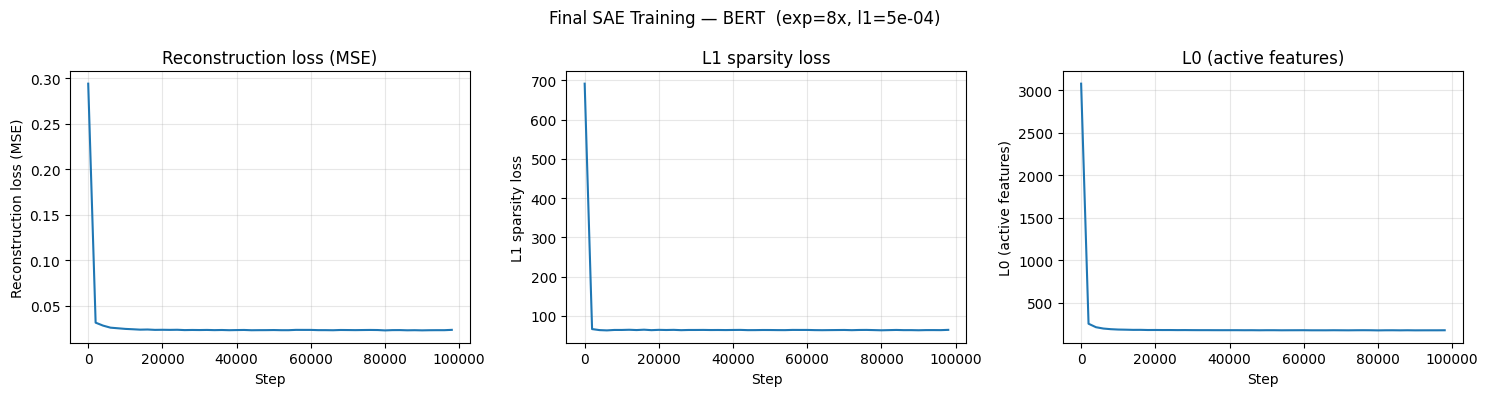

Saved: /content/drive/MyDrive/EMI_Project/activations/sae/bert/final_training_curves.png


In [ ]:
# Training curves for final run
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, ylabel in zip(
    axes,
    ['recon', 'l1', 'l0'],
    ['Reconstruction loss (MSE)', 'L1 sparsity loss', 'L0 (active features)'],
):
    ax.plot(final_history['step'], final_history[key], lw=1.5)
    ax.set_xlabel('Step')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Final SAE Training — {MODEL.upper()}  '
             f'(exp={BEST_EXPANSION}x, l1={BEST_L1:.0e})', fontsize=12)
plt.tight_layout()
curve_path = os.path.join(OUTPUT_DIR, 'final_training_curves.png')
plt.savefig(curve_path, dpi=150)
plt.show()
print(f'Saved: {curve_path}')

## Save Model and Results

In [ ]:
# Save model weights
model_path = os.path.join(OUTPUT_DIR, f'sae_{MODEL}_exp{BEST_EXPANSION}_l1{BEST_L1:.0e}.pt')
torch.save({
    'model_state_dict': final_model.state_dict(),
    'config': {
        'model':          MODEL,
        'd_in':           D_IN,
        'd_sae':          BEST_D_SAE,
        'expansion':      BEST_EXPANSION,
        'l1_coeff':       BEST_L1,
        'n_steps':        FINAL_STEPS,
        'batch_size':     BATCH_SIZE,
        'learning_rate':  LEARNING_RATE,
        'n_activations':  N,
        'act_mean':       act_mean.tolist(),
    },
    'final_recon': final_history['recon'][-1],
    'final_l0':    final_history['l0'][-1],
}, model_path)
print(f'Model saved : {model_path}')

# Save sweep results (without model objects)
sweep_path = os.path.join(OUTPUT_DIR, 'grid_search_results.json')
with open(sweep_path, 'w') as f:
    json.dump([
        {k: v for k, v in r.items() if k != 'history'}
        for r in sweep_results
    ], f, indent=2)
print(f'Sweep results saved : {sweep_path}')

# Summary
print()
print('=' * 50)
print('SAE TRAINING COMPLETE')
print('=' * 50)
print(f'Model       : {MODEL.upper()}')
print(f'd_in        : {D_IN}')
print(f'd_sae       : {BEST_D_SAE}  ({BEST_EXPANSION}x expansion)')
print(f'L1 coeff    : {BEST_L1:.0e}')
print(f'Recon loss  : {final_history["recon"][-1]:.6f}')
print(f'L0          : {final_history["l0"][-1]:.1f} / {BEST_D_SAE} features active')
print(f'Params      : {final_model.n_params():,}')
print(f'Output dir  : {OUTPUT_DIR}')

Model saved : /content/drive/MyDrive/EMI_Project/activations/sae/bert/sae_bert_exp8_l15e-04.pt
Sweep results saved : /content/drive/MyDrive/EMI_Project/activations/sae/bert/grid_search_results.json

SAE TRAINING COMPLETE
Model       : BERT
d_in        : 768
d_sae       : 6144  (8x expansion)
L1 coeff    : 5e-04
Recon loss  : 0.023801
L0          : 176.2 / 6144 features active
Params      : 9,444,096
Output dir  : /content/drive/MyDrive/EMI_Project/activations/sae/bert


## Load a Saved SAE

Use this cell to reload the model in a future session without retraining.

In [ ]:
def load_sae(path: str, device=device) -> SparseAutoencoder:
    checkpoint = torch.load(path, map_location=device)
    cfg = checkpoint['config']
    model = SparseAutoencoder(cfg['d_in'], cfg['d_sae']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Loaded SAE: d_in={cfg['d_in']}  d_sae={cfg['d_sae']}  "
          f"recon={checkpoint['final_recon']:.6f}  l0={checkpoint['final_l0']:.1f}")
    return model, cfg

# Example usage:
# sae, cfg = load_sae(model_path)

In [ ]:
# ── Select model ─────────────────────────────────────────────────────────────
MODEL       = 'gpt2'    # 'bert' or 'gpt2'
N_SPEECHES  = 1000000     # must match the number used when collecting activations

# ── Paths ─────────────────────────────────────────────────────────────────────
ACTIVATIONS_DIR = '/content/drive/MyDrive/EMI_Project/activations'
OUTPUT_DIR      = f'/content/drive/MyDrive/EMI_Project/activations/sae/{MODEL}'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ACT_PATH  = os.path.join(ACTIVATIONS_DIR, f'{MODEL}_last_{N_SPEECHES}.npy')
META_PATH = os.path.join(ACTIVATIONS_DIR, f'{MODEL}_metadata_{N_SPEECHES}.json')

# ── Grid search hyperparameters ───────────────────────────────────────────────
EXPANSION_FACTORS = [4, 8]
# L1 values scaled for sum-over-features formulation (not mean)
L1_COEFFS = [1e-5, 1e-4, 1e-3, 5e-3, 1e-2]


SWEEP_FRACTION = 0.10   # fraction of data used for grid search
SWEEP_STEPS    = 8_000  # optimiser steps per sweep run (~fast)

# ── Final training ────────────────────────────────────────────────────────────
FINAL_STEPS    = 100_000
BATCH_SIZE     = 4096
LEARNING_RATE  = 1e-4
SEED           = 42

print(f'Activation file : {ACT_PATH}')
print(f'Output dir      : {OUTPUT_DIR}')

Activation file : /content/drive/MyDrive/EMI_Project/activations/gpt2_last_1000000.npy
Output dir      : /content/drive/MyDrive/EMI_Project/activations/sae/gpt2


In [ ]:
assert os.path.isfile(ACT_PATH),  f'Activations not found: {ACT_PATH}'
assert os.path.isfile(META_PATH), f'Metadata not found: {META_PATH}'

print('Loading activations...')
activations_np = np.load(ACT_PATH).astype(np.float32)
print(f'Shape  : {activations_np.shape}   dtype: {activations_np.dtype}')
print(f'Min    : {activations_np.min():.4f}   Max: {activations_np.max():.4f}')
print(f'Memory : {activations_np.nbytes / 1e9:.2f} GB')

act_scale = float(np.sqrt((activations_np ** 2).mean()))
activations_np /= act_scale
print(f'Activation RMS scale: {act_scale:.4f}  (activations now unit-RMS)')


D_IN = activations_np.shape[1]
N    = activations_np.shape[0]
print(f'\nd_in = {D_IN}   n_activations = {N:,}')

# Centre activations — SAE pre-encoder bias handles the mean
act_mean = activations_np.mean(axis=0, keepdims=True)
activations_np -= act_mean
print('Activations centred (mean subtracted).')

activations_tensor = torch.from_numpy(activations_np)

Loading activations...
Shape  : (1000000, 1024)   dtype: float32
Min    : -107.4973   Max: 106.3538
Memory : 4.10 GB
Activation RMS scale: 1.7623  (activations now unit-RMS)

d_in = 1024   n_activations = 1,000,000
Activations centred (mean subtracted).


In [ ]:
torch.manual_seed(SEED)
n_subset  = int(N * SWEEP_FRACTION)
idx       = torch.randperm(N)[:n_subset]
subset    = activations_tensor[idx]

print(f'Grid search subset: {n_subset:,} activations  ({SWEEP_FRACTION*100:.0f}% of {N:,})')
print(f'Configs: {len(EXPANSION_FACTORS)} expansion factors × {len(L1_COEFFS)} L1 coeffs '
      f'= {len(EXPANSION_FACTORS)*len(L1_COEFFS)} runs')
print(f'Steps per run: {SWEEP_STEPS:,}\n')

sweep_results = []

for exp, l1 in itertools.product(EXPANSION_FACTORS, L1_COEFFS):
    d_sae = D_IN * exp
    label = f'exp={exp}x  l1={l1:.0e}'
    print(f'Running: {label}  (d_sae={d_sae})')

    model, history = train_sae(
        data      = subset,
        d_sae     = d_sae,
        l1_coeff  = l1,
        n_steps   = SWEEP_STEPS,
        desc      = label,
    )

    sweep_results.append({
        'expansion':    exp,
        'l1_coeff':     l1,
        'd_sae':        d_sae,
        'label':        label,
        'final_recon':  history['recon'][-1],
        'final_l0':     history['l0'][-1],
        'history':      history,
    })

print('\nGrid search complete.')

Grid search subset: 100,000 activations  (10% of 1,000,000)
Configs: 2 expansion factors × 5 L1 coeffs = 10 runs
Steps per run: 8,000

Running: exp=4x  l1=1e-05  (d_sae=4096)
  [exp=4x  l1=1e-05] done in 208s  final recon=0.0005  l0=1721.7     
Running: exp=4x  l1=1e-04  (d_sae=4096)
  [exp=4x  l1=1e-04] done in 206s  final recon=0.0045  l0=385.8     
Running: exp=4x  l1=1e-03  (d_sae=4096)
  [exp=4x  l1=1e-03] done in 207s  final recon=0.0206  l0=39.3     
Running: exp=4x  l1=5e-03  (d_sae=4096)
  [exp=4x  l1=5e-03] done in 206s  final recon=0.0603  l0=5.3     
Running: exp=4x  l1=1e-02  (d_sae=4096)
  [exp=4x  l1=1e-02] done in 206s  final recon=0.0831  l0=0.6     
Running: exp=8x  l1=1e-05  (d_sae=8192)
  [exp=8x  l1=1e-05] done in 233s  final recon=0.0006  l0=1993.1     
Running: exp=8x  l1=1e-04  (d_sae=8192)
  [exp=8x  l1=1e-04] done in 234s  final recon=0.0043  l0=384.3     
Running: exp=8x  l1=1e-03  (d_sae=8192)
  [exp=8x  l1=1e-03] done in 234s  final recon=0.0213  l0=38.9   